In [7]:
import pandas as pd

data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/CMD_2024_Original.csv')
data

# %%
# Mapping binary classification
binary_mapping = {
    'no malware': 0,  # Benign
    'virus': 1,
    'trojan': 1,
    'worm': 1,
    'ransomware': 1,
    'adware': 1,
    'miner': 1,
    'pua': 1,
    'downloader': 1
}

data['Label'] = data['Label'].map(binary_mapping)
print(data['Label'].value_counts())

# %%
print("Sebelum drop NaN:")
print(f"Jumlah data: {len(data)}")
print(data['Label'].value_counts(dropna=False))

data = data.dropna(subset=['Label'])

print("\nSetelah drop NaN:")
print(f"Jumlah data: {len(data)}")
print(data['Label'].value_counts())

# %%
ft = ['MD5', 'SHA1', 'SHA256']
data = data.drop(columns=ft)

class_labels = sorted(data['Label'].unique().tolist())
class_labels


Label
1.0    15834
0.0     5016
Name: count, dtype: int64
Sebelum drop NaN:
Jumlah data: 20860
Label
1.0    15834
0.0     5016
NaN       10
Name: count, dtype: int64

Setelah drop NaN:
Jumlah data: 20850
Label
1.0    15834
0.0     5016
Name: count, dtype: int64


[0.0, 1.0]

In [8]:
from sklearn.model_selection import train_test_split

# ==========================
# Train-Test Split
# ==========================
X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test  : {X_test.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of y_test  : {y_test.shape}")

Shape of X_train : (16680, 236)
Shape of X_test  : (4170, 236)
Shape of y_train : (16680,)
Shape of y_test  : (4170,)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import pandas as pd
import time

# ============================================
# Helper
# ============================================
results = []

def print_metrics(name, y_true, y_pred, training_time=None, testing_time=None):
    acc = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Training Time : {training_time:.4f} s")
    print(f"Testing Time  : {testing_time:.4f} s")
    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {prec_w:.4f}")
    print(f"Precision Macro : {prec_m:.4f}")
    print(f"Recall        : {rec_w:.4f}")
    print(f"Recall Macro  : {rec_m:.4f}")
    print(f"F1-Score      : {f1_w:.4f}")
    print(f"F1 Macro      : {f1_m:.4f}")

    print("\nClassification Report\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[str(c) for c in sorted(y.unique())],
        zero_division=0
    ))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec_w,
        "Precision Macro": prec_m,
        "Recall": rec_w,
        "Recall Macro": rec_m,
        "F1": f1_w,
        "F1 Macro": f1_m,
        "Training Time (s)": training_time,
        "Testing Time (s)": testing_time
    })

# ===================================================
# Data langsung dari train_test_split (tanpa PCA)
# ===================================================
Xtr = X_train
Xts = X_test

# ===================================================
# Random Forest
# ===================================================
print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_model.fit(Xtr, y_train)
rf_train = time.time() - start

start = time.time()
rf_pred = rf_model.predict(Xts)
rf_test = time.time() - start

print_metrics("Random Forest", y_test, rf_pred, rf_train, rf_test)

# ===================================================
# XGBoost
# ===================================================
print("\nTraining XGBoost...")

# scale_pos_weight membantu menangani class imbalance (setara class_weight="balanced")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

start = time.time()
xgb_model.fit(Xtr, y_train)
xgb_train = time.time() - start

start = time.time()
xgb_pred = xgb_model.predict(Xts)
xgb_test = time.time() - start

print_metrics("XGBoost", y_test, xgb_pred, xgb_train, xgb_test)

# ===================================================
# Summary
# ===================================================
results_df = pd.DataFrame(results)

print("\nSummary Results")
display(results_df.round(4))


Training Random Forest...

Random Forest
Training Time : 2.0640 s
Testing Time  : 0.0860 s
Accuracy      : 0.9839
Precision     : 0.9839
Precision Macro : 0.9824
Recall        : 0.9839
Recall Macro  : 0.9734
F1-Score      : 0.9839
F1 Macro      : 0.9778

Classification Report

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.97      1003
         1.0       0.99      0.99      0.99      3167

    accuracy                           0.98      4170
   macro avg       0.98      0.97      0.98      4170
weighted avg       0.98      0.98      0.98      4170


Training XGBoost...

XGBoost
Training Time : 1.1851 s
Testing Time  : 0.0140 s
Accuracy      : 0.9926
Precision     : 0.9926
Precision Macro : 0.9903
Recall        : 0.9926
Recall Macro  : 0.9893
F1-Score      : 0.9926
F1 Macro      : 0.9898

Classification Report

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1003
         1.0      

,Model,Accuracy,Precision,Precision Macro,Recall,Recall Macro,F1,F1 Macro,Training Time (s),Testing Time (s)
0,Random Forest,0.9839,0.9839,0.9824,0.9839,0.9734,0.9839,0.9778,2.0640,0.086
1,XGBoost,0.9926,0.9926,0.9903,0.9926,0.9893,0.9926,0.9898,1.1851,0.014


Feature Importance - XGBoost


,Feature,Importance
0,PE32/PE64,0.114334
1,NtDeleteKey,0.101909
2,Digital Sign,0.090447
3,NtDeleteAtom,0.088027
4,NtWaitForMultipleObjects32,0.087188
...,...,...
231,NtFW,0.000000
232,NtFv,0.000000
233,NtFU,0.000000
234,NtFsControlFile,0.000000


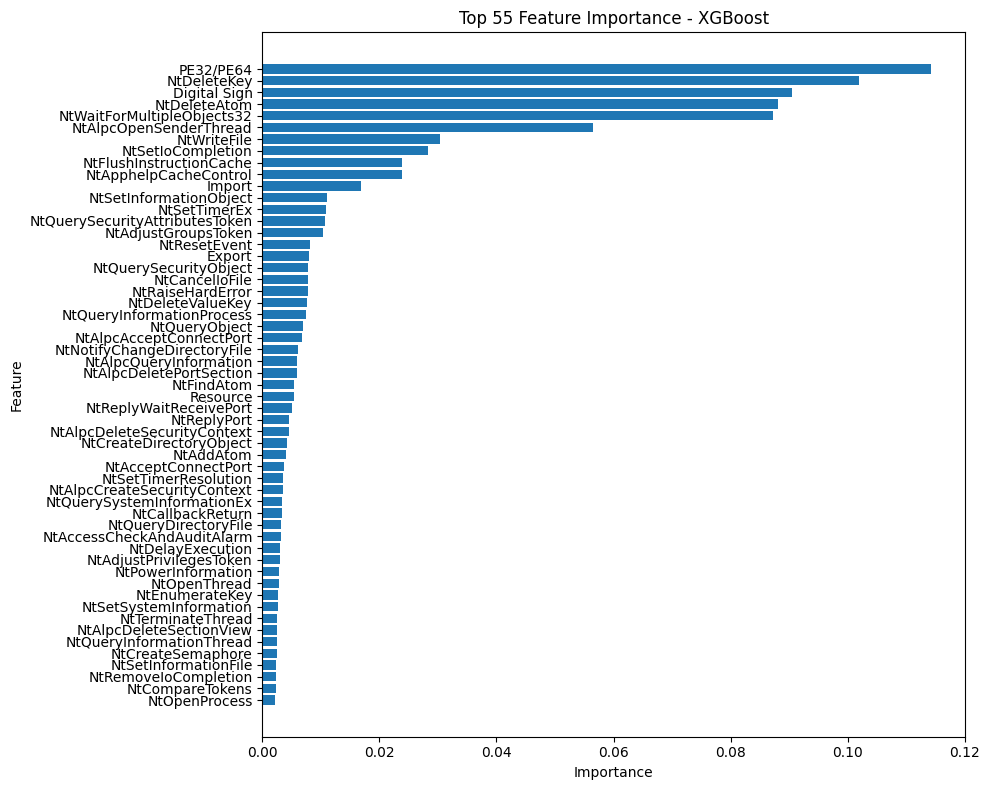

In [11]:
# %%
import matplotlib.pyplot as plt
import pandas as pd

# ===================================================
# Feature Importance - XGBoost
# ===================================================

# Ambil feature importance dari model
importance = xgb_model.feature_importances_

# Buat DataFrame supaya rapi dan mudah dibaca
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Feature Importance - XGBoost")
display(feature_importance_df)

# ===================================================
# Visualisasi - Top N Feature Importance
# ===================================================
top_n = 55  # ubah sesuai kebutuhan

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df['Feature'][:top_n][::-1],
    feature_importance_df['Importance'][:top_n][::-1]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()